#### **ARCHITECTURE AND WORKFLOW**

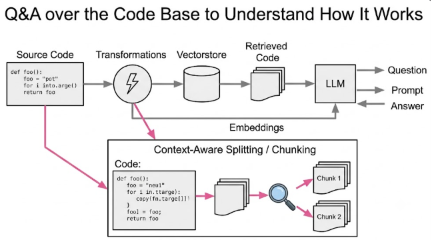

In [ ]:
# Imports the Repo class from GitPython to interact with git repositories (e.g., to clone a codebase you want to analyze)
from git import Repo 

# Imports the Language enum to specify programming languages (like Python, JS) so LangChain knows how to parse the syntax
from langchain_classic.text_splitter import Language 

# A flexible document loader used to load files (like your source code files) from a directory
from langchain_community.document_loaders.generic import GenericLoader 

# A specialized parser that reads and understands the structure of source code files based on the specified programming language
from langchain_community.document_loaders.parsers import LanguageParser 

# A tool that breaks large text (or code) into smaller chunks so the AI can process them without hitting token limits
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter 

# Standard Python library for interacting with the operating system (like checking file paths or setting environment variables)
import os 

# Converts text/code chunks into numerical vectors (embeddings) so they can be searched mathematically
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Imports Chroma, a local vector database used to store and query your code embeddings
from langchain_classic.vectorstores import Chroma 

# The main wrapper for interacting with OpenAI's chat models (like GPT-3.5 or GPT-4)
from langchain_google_genai import ChatGoogleGenerativeAI

# A memory component that summarizes past chat history so the AI remembers context during a back-and-forth conversation
from langchain_classic.memory import ConversationSummaryMemory 

# The logic chain that ties everything together: it takes your question, retrieves relevant code chunks from Chroma, and passes them to the LLM to generate an answer
from langchain_classic.chains import ConversationalRetrievalChain

c:\Users\ADITHYA UBALE\miniconda3\envs\llm-app\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ADITHYA UBALE\AppData\Local\Temp\ipykernel_23732\2540556547.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders.generic import GenericLoader


In [2]:
%pwd

'c:\\Users\\ADITHYA UBALE\\OneDrive\\Desktop\\ADITHYA_GENAI\\ADITHYA-GENAI\\projects\\End_to_End_SourceCode_Analysis\\research'

In [3]:
!mkdir test_repo

A subdirectory or file test_repo already exists.


In [ ]:
repo_path = "test_repo/"
repo = Repo.clone_from("https://github.com/adithyaubale2006-hub/ADITHYA-GENAI.git", to_path= repo_path)

In [6]:
# Sets up a document loader to search through the cloned repository
loader = GenericLoader.from_filesystem(repo_path,
                                       glob="**/*",
                                       suffixes=[".py"],
                                       parser=LanguageParser(language=Language.PYTHON))

In [7]:
# 1. Execute the loader to parse all the .py files
documents = loader.load()

# 2. Test how many documents were successfully loaded
print(f"Total documents loaded: {len(documents)}")

# 3. Inspect the parsed content of the first document to verify
print("--- First Document Content ---")
print(documents[0].page_content)

Total documents loaded: 144
--- First Document Content ---
def build_rag_chain():
	if not os.getenv("NVIDIA_API_KEY"):
		raise RuntimeError("NVIDIA_API_KEY is missing. Add it to your .env file to enable answers.")

	documents = UnstructuredURLLoader(urls=SOURCE_URLS).load()
	splitter = RecursiveCharacterTextSplitter(
		separators=["\n"], chunk_size=1000, chunk_overlap=0
	)
	chunks = splitter.split_documents(documents)
	embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
	vector_store = Chroma.from_documents(documents=chunks, embedding=embeddings)
	retriever = vector_store.as_retriever(
		search_type="similarity", search_kwargs={"k": 3}
	)
	llm = ChatNVIDIA(
		model="openai/gpt-oss-20b",
		api_key=os.environ["NVIDIA_API_KEY"],
		max_tokens=200,
		temperature=0.2,
		top_p=1,
	)
	prompt = ChatPromptTemplate.from_messages(
		[
			(
				"system",
				"You are an assistant for question-answering tasks. "
				"Use the retrieved context to answer the question. "
				"If you don't

In [8]:
documents_splitter = RecursiveCharacterTextSplitter.from_language(language = Language.PYTHON,
                                                                  chunk_size = 500,
                                                                  chunk_overlap = 20)

In [9]:
text = documents_splitter.split_documents(documents)

In [10]:
len(text)

398

In [11]:
text[0].page_content

'def build_rag_chain():\n\tif not os.getenv("NVIDIA_API_KEY"):\n\t\traise RuntimeError("NVIDIA_API_KEY is missing. Add it to your .env file to enable answers.")'

In [12]:
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

In [ ]:
!pip install sentence-transformers

^C


In [13]:
# Import the Hugging Face embeddings class
from langchain_community.embeddings import HuggingFaceEmbeddings

# Initialize the embeddings using a popular open-source sentence transformer model
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

C:\Users\ADITHYA UBALE\AppData\Local\Temp\ipykernel_23732\3263565030.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2700.67it/s]


In [14]:
vectordb = Chroma.from_documents(text, embedding=embeddings, persist_directory='./db')
vectordb.persist()

C:\Users\ADITHYA UBALE\AppData\Local\Temp\ipykernel_23732\340097968.py:2: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [20]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key = GEMINI_API_KEY,
    temperature=0.1,
    max_tokens=1000
)

In [16]:
memory = ConversationSummaryMemory(llm=llm, memory_key="chat_history", return_messages=True)

C:\Users\ADITHYA UBALE\AppData\Local\Temp\ipykernel_23732\1764516168.py:1: LangChainDeprecationWarning: The class `ConversationSummaryMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  memory = ConversationSummaryMemory(llm=llm, memory_key="chat_history", return_messages=True)


In [17]:
qa = ConversationalRetrievalChain.from_llm(llm, retriever=vectordb.as_retriever(search_type="mmr", search_kwargs={"k":8}))

In [18]:
question = "What is download_hugging_face_embedding Function"

In [19]:
# Pass an empty list to satisfy the missing key requirement
result = qa.invoke({
    "question": question,
    "chat_history": []
})

print(result["answer"])

c:\Users\ADITHYA UBALE\miniconda3\envs\llm-app\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Based on the provided context, the `download_hugging_face_embeddings()` function is a Python function that loads and returns an embedding model using LangChain's `HuggingFaceEmbeddings`. 

Specifically, it initializes the Hugging Face embedding model:
`"sentence-transformers/all-MiniLM-L6-v2"`

**Function definition from the code:**
```python
def download_hugging_face_embeddings():
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
    return embeddings
```

It is used in the text processing pipeline to convert extracted text chunks into vector embeddings.
